# Dropping the symmetry requirement: the no-symmetry tile census

Every census in this repository so far — 1, 2, 7, 85, 2632, 332321, 108492376
for levels 1–7 — counts tiles that are **D4-symmetric** by construction: the
solver works on one variable per symmetry orbit, so every solution is invariant
under all rotations and reflections of the tile.

This notebook asks what happens when that requirement is dropped, keeping
everything else:

- the tile is a **still life** under the Conway rule,
- the **pond frame** is forced alive,
- the full orbit-closed **dead-edge set** is forced dead, so tiles still cannot
  interact across mosaic seams (mosaic compatibility is preserved).

Mechanically this is a small change: `Domain` is symmetry-agnostic, and D4
enters the verified pipeline only through `build_domain`'s orbit-representative
arrays. `nosym_tiles.build_nosym_domain` builds an **identity-orbit domain**
(each cell its own orbit) over the same forced masks; the shared clause builder
and the AllSAT enumeration do the rest. One subtlety matters: the dead edges
must be the *full orbit-closed set* (`derive_dead_edges_full`) — octant
representatives would no longer propagate without the symmetry constraint.

The symmetric pipeline (`build_domain`, `build_cnf`, their pinned SHA-256
fingerprints, and all shipped censuses) is untouched.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gol_mosaics import nosym_tiles, sat_search
from gol_mosaics.nosym_tiles import (
    EXPECTED_FREE_CELLS,
    build_nosym_domain,
    d4_classes,
    d4_fixed_counts,
    enumerate_nosym_tiles,
    load_nosym_tiles,
)

## The identity domain

Without symmetry, every unforced cell is a decision variable. The counts grow
from 1 / 3 / 10 free *orbits* (levels 1–3, D4-reduced) to 4 / 16 / 68 free
*cells*:

In [2]:
for level in (1, 2, 3, 4):
    domain = build_nosym_domain(level)
    sym = sat_search.build_domain(level)
    print(f"level {level}: n={domain.n:2d}  free cells={len(domain.free_reps):3d}  "
          f"(vs {len(sym.free_reps):2d} free orbits with D4)")

level 1: n= 6  free cells=  4  (vs  1 free orbits with D4)
level 2: n=12  free cells= 16  (vs  3 free orbits with D4)
level 3: n=18  free cells= 68  (vs 10 free orbits with D4)
level 4: n=24  free cells=156  (vs 22 free orbits with D4)


## Enumeration, levels 1–3

Exact AllSAT with blocking clauses, exactly as for the symmetric censuses. The
counts are tiny by SAT standards — the whole thing takes a fraction of a
second.

In [3]:
tiles = {}
for level in (1, 2, 3):
    t0 = time.time()
    tiles[level] = enumerate_nosym_tiles(level)
    print(f"level {level}: {len(tiles[level]):5d} tiles in {time.time() - t0:.2f} s")

level 1:     1 tiles in 1.57 s
level 2:     2 tiles in 0.08 s


level 3:  1061 tiles in 1.29 s


## The census

Raw counts, D4 equivalence classes, and how the classes decompose by orbit
size. A class of size 1 is a fully D4-symmetric tile; size 8 is a tile with no
symmetry at all; sizes 2 and 4 have partial symmetry (a stabiliser of order 4
or 2 respectively).

In [4]:
symmetric_census = {1: 1, 2: 2, 3: 7}
print(f"{'level':>5} {'raw':>6} {'classes':>8} {'symmetric':>10}   class sizes")
for level in (1, 2, 3):
    classes = d4_classes(tiles[level])
    sizes = {}
    for members in classes.values():
        sizes[len(members)] = sizes.get(len(members), 0) + 1
    print(f"{level:>5} {len(tiles[level]):>6} {len(classes):>8} "
          f"{symmetric_census[level]:>10}   {dict(sorted(sizes.items()))}")

level    raw  classes  symmetric   class sizes
    1      1        1          1   {1: 1}
    2      2        2          2   {1: 2}
    3   1061      181          7   {1: 7, 2: 9, 4: 71, 8: 94}


Levels 1 and 2 are **unchanged**: every tile satisfying the frame, dead-edge
and stability constraints at those sizes happens to be D4-symmetric anyway.
Level 3 is where asymmetry appears: the census explodes from 7 to **1061 raw
grids**, forming **181 equivalence classes** — 7 fully symmetric (the old
census), 9 + 71 partially symmetric, and 94 with no symmetry at all.

## Cross-checks

Three independent consistency checks:

1. every tile is stable (vectorised toroidal rule check, no SAT involved),
2. the singleton classes at level 3 are *exactly* the historical symmetric
   census,
3. **Burnside's lemma**: for a D4-closed set, `sum_g |Fix(g)| = |D4| x #classes`.

In [5]:
for level in (1, 2, 3):
    assert not sat_search.rule_violations(tiles[level]).any()
print("all tiles stable")

classes3 = d4_classes(tiles[3])
singletons = {tiles[3][m[0]].tobytes() for m in classes3.values() if len(m) == 1}
old_census = {np.ascontiguousarray(g).tobytes() for g in sat_search.enumerate_tiles(3)}
assert singletons == old_census
print("singleton classes == symmetric census (7 tiles)")

fixed = d4_fixed_counts(tiles[3])
print(f"per-transform fixed counts: {fixed}")
assert sum(fixed) == 8 * len(classes3) == 1448
print(f"Burnside: sum|Fix| = {sum(fixed)} = 8 x {len(classes3)} classes")

all tiles stable


singleton classes == symmetric census (7 tiles)


per-transform fixed counts: [1061, 87, 7, 85, 29, 87, 7, 85]
Burnside: sum|Fix| = 1448 = 8 x 181 classes


## A gallery of asymmetric tiles

One representative from each of the twelve most populous level-3 classes with
trivial stabiliser (orbit size 8) — designs the symmetric search could never
see.

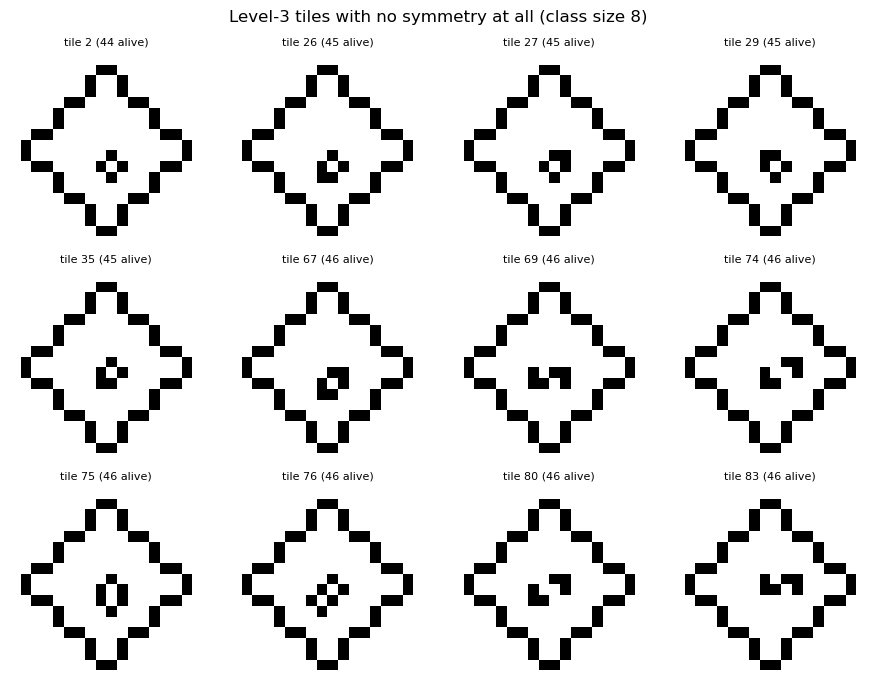

In [6]:
asymmetric = [m[0] for m in classes3.values() if len(m) == 8]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, idx in zip(axes.ravel(), asymmetric[:12]):
    ax.imshow(tiles[3][idx], cmap="binary", interpolation="nearest")
    ax.set_title(f"tile {idx} ({int(tiles[3][idx].sum())} alive)", fontsize=8)
    ax.axis("off")
fig.suptitle("Level-3 tiles with no symmetry at all (class size 8)")
fig.tight_layout()
plt.show()

## The shipped artifact

The level-3 census ships with the package as packed free-cell bits
(`solutions_pattern_nosym_level_3_cells.npy`, 1061 x 9 bytes ~ 9.7 KB): one
bit per free cell of the identity domain, MSB-first, rows in canonical
(live-cell count, grid bytes) order. `load_nosym_tiles` expands it back to
full grids; it must be byte-identical to a fresh enumeration.

In [7]:
assert np.array_equal(load_nosym_tiles(3), tiles[3])
print("shipped file == fresh enumeration, byte-identical")

shipped file == fresh enumeration, byte-identical


## Outlook: level 4 and beyond

At level 4 the identity domain has **156 free cells**, and a single-shot
AllSAT probe passed **two million models without exhausting the space** — the
census is at least 3 x 10^5 times the symmetric count of 85, and a single
blocking-clause loop degrades badly at that scale (every found model becomes a
permanent clause the solver re-propagates). The level-4 census is therefore
left uncomputed here.

The road is prepared, though: `workstation/nosym_search/search_nosym.py`
implements the same cube-and-conquer split that carried the symmetric level-7
census (108,492,376 tiles in ~2.25 h of solving), its `self-test` reproduces
the level-3 census through the cube path byte-exactly, and `REPRODUCE.md`
records the recipe. One practical lesson is baked into the defaults: use
*fine* cubes (`--cube-bits 16`) — with a coarse split a handful of tail cubes
hold nearly the entire census and per-cube degradation returns.

In [8]:
from gol_mosaics.nosym_tiles import EXPECTED_FREE_CELLS

for level, cells_ in sorted(EXPECTED_FREE_CELLS.items()):
    sym = sat_search.build_domain(level)
    print(f"level {level}: {cells_:3d} free cells "
          f"(vs {len(sym.free_reps):2d} D4 orbits) — "
          + ("census known" if level <= 3 else "census open (> 2e6)"))

level 1:   4 free cells (vs  1 D4 orbits) — census known
level 2:  16 free cells (vs  3 D4 orbits) — census known
level 3:  68 free cells (vs 10 D4 orbits) — census known
level 4: 156 free cells (vs 22 D4 orbits) — census open (> 2e6)
